In [20]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from typing import List, Optional, Tuple

In [12]:
def generate_data(B: int, d: int, N: int, R: float, is_validation: bool = False, label_flip_p: float = 0.0):
    mus = torch.randn(B, d)
    mus = mus / torch.norm(mus, dim=1, keepdim=True) * R
    
    y_all = (torch.rand(B, N + 1) > 0.5).float()

    y_signal = 2 * y_all - 1

    z = torch.randn(B, N + 1, d)

    x = y_signal[..., None] * mus[:, None, :] + z

    if label_flip_p:
        flip_mask = (torch.rand(B, N + 1) < label_flip_p)
        y_all = torch.where(flip_mask, 1 - y_all, y_all)
    
    context_x = x[:, :N, :]  # (B, N, d)
    target_x = x[:, -1, :]        # (B, d)
    context_y = y_all[:, :N]  # (B, N)
    target_y = y_all[:, -1]       # (B)
    
    return context_x, context_y, target_x, target_y

In [57]:
class LinearTransformer(nn.Module):
    def __init__(self, d: int):
        super().__init__()
        self.W = nn.Parameter(torch.zeros(d, d))

    def forward(self, context_x: torch.Tensor, context_y: torch.Tensor, target_x: torch.Tensor) -> torch.Tensor:
        N = context_x.shape[1]

        context_y_signal = 2 * context_y - 1

        context_term = (1/N) * torch.sum(context_y_signal[..., None] * context_x, dim=1)
        
        # 1. Transform context: (B, d) @ (d, d) -> (B, d)
        # 2. Take inner product with target: (B, d) * (B, d) -> (B,)
        transformed = context_term @ self.W
        logits = (transformed * target_x).sum(dim=1)
        return logits
    
    def compute_in_context_preds(self, context_x: torch.Tensor, context_y: torch.Tensor) -> torch.Tensor:
        B, N, d = context_x.shape

        # Normalize each input vector - output is homogeneous in x, so this won't affect
        # decision boundary, and we are only using this at test time so no change in optimization
        context_x = context_x / torch.norm(context_x, dim=2, keepdim=True)
        context_y_signal = 2 * context_y - 1
        # (B, N, 1) * (B, N, d) -> (B, N, d) -> (B, d)
        hat_mu = (1/N) * torch.sum(context_y_signal[..., None] * context_x, dim=1)

        # compute hat_mu_\tau^T W for each \tau = 1, ... , B
        transformed = hat_mu @ self.W # (B,d)
        # now compute hat_mu_\tau^T W x_i for i=1, ..., N
        # Shapes (B, 1, d) @ (B, d, N) -> (B, 1, N)
        logits = transformed[:, None, :] @ context_x.transpose(-1, -2)
        predictions = (logits[:, 0, :] > 0).float()
        return predictions

In [120]:
def train(
    d,
    B,
    N,
    R,
    steps=300,
    lr=1e-2,
    val_every=50,
    label_flip_p=0.0,
    device="cuda" if torch.cuda.is_available() else "cpu"
):

    model = LinearTransformer(d).to(device)
    opt = optim.SGD(model.parameters(), lr=lr, momentum=0.0)

    for step in range(steps):

        # ---- generate train batch ----
        context_x, context_y, target_x, target_y = generate_data(
            B=B, d=d, N=N, R=R, is_validation=False, label_flip_p=0.0
        )

        context_x = context_x.to(device)
        context_y = context_y.to(device)
        target_x = target_x.to(device)
        target_y = target_y.to(device)

        # ---- forward pass ----
        logits = model(context_x, context_y, target_x)
        loss = torch.nn.functional.binary_cross_entropy_with_logits(logits, target_y.float())

        # ---- update ----
        opt.zero_grad()
        loss.backward()
        opt.step()

        # ---- logging ----
        if step % val_every == 0:
            with torch.no_grad():
                preds = (logits > 0).float()
                acc = (preds == target_y).float().mean().item()

            # ---- validation batch ----
            val_cx, val_cy, val_tx, val_ty = generate_data(
                B=B, d=d, N=N, R=R, is_validation=True, label_flip_p=label_flip_p
            )
            val_cx = val_cx.to(device)
            val_cy = val_cy.to(device)
            val_tx = val_tx.to(device)
            val_ty = val_ty.to(device)

            val_logits = model(val_cx, val_cy, val_tx)
            val_loss = torch.nn.functional.binary_cross_entropy_with_logits(val_logits, val_ty.float())
            val_preds = (val_logits > 0).float()
            val_acc = (val_preds == val_ty).float().mean().item()

            print(f"Step {step:5d} | "
                  f"train loss = {loss.item():.4f} | "
                  f"train acc = {acc:.3f} | "
                  f"val loss= {val_loss.item():.4f} | "
                  f"val acc = {val_acc:.3f}"
            )

    return model, acc, val_acc

In [106]:
d, B, N = 1000, 100, 20
R = d ** 0.3

train(d, B, N, R, label_flip_p=0.2, val_every=50)

Step     0 | train loss = 0.6931 | train acc = 0.510 | val loss= 0.6874 | val acc = 0.590
Step    50 | train loss = 0.3767 | train acc = 0.990 | val loss= 0.6138 | val acc = 0.690
Step   100 | train loss = 0.2780 | train acc = 0.990 | val loss= 0.4701 | val acc = 0.870
Step   150 | train loss = 0.1823 | train acc = 1.000 | val loss= 0.5592 | val acc = 0.760
Step   200 | train loss = 0.1536 | train acc = 1.000 | val loss= 0.5155 | val acc = 0.810
Step   250 | train loss = 0.1206 | train acc = 1.000 | val loss= 0.4936 | val acc = 0.840


LinearTransformer()

In [114]:
d, B, N = 1000, 100, 20
R = d ** 0.1

train(d, B, N, R, label_flip_p=0.2, val_every=50)

Step     0 | train loss = 0.6931 | train acc = 0.440 | val loss= 0.6920 | val acc = 0.540
Step    50 | train loss = 0.6814 | train acc = 0.550 | val loss= 0.6837 | val acc = 0.600
Step   100 | train loss = 0.7019 | train acc = 0.550 | val loss= 0.7080 | val acc = 0.500
Step   150 | train loss = 0.7203 | train acc = 0.420 | val loss= 0.7200 | val acc = 0.470
Step   200 | train loss = 0.7266 | train acc = 0.410 | val loss= 0.7230 | val acc = 0.430
Step   250 | train loss = 0.6504 | train acc = 0.670 | val loss= 0.7130 | val acc = 0.500


LinearTransformer()

In [119]:
d, B, N = 1000, 100, 20
R = d ** 0.3

train(d, B, N, R, label_flip_p=0.2, val_every=50)

Step     0 | train loss = 0.6931 | train acc = 0.550 | val loss= 0.6915 | val acc = 0.540
Step    50 | train loss = 0.4063 | train acc = 0.990 | val loss= 0.5823 | val acc = 0.770
Step   100 | train loss = 0.2731 | train acc = 0.990 | val loss= 0.5986 | val acc = 0.720
Step   150 | train loss = 0.1928 | train acc = 0.990 | val loss= 0.5582 | val acc = 0.760
Step   200 | train loss = 0.1453 | train acc = 1.000 | val loss= 0.5565 | val acc = 0.790
Step   250 | train loss = 0.1324 | train acc = 1.000 | val loss= 0.5916 | val acc = 0.740


LinearTransformer()

In [125]:
import matplotlib.pyplot as plt

In [129]:
ds = [10, 50, 100, 500, 1000]
train_accs, val_accs = [], []

for d in ds:
    B, N = 100, 20
    R = d ** 0.1
    _, train_acc, val_acc = train(d, B, N, R, label_flip_p=0.2, val_every=50)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

Step     0 | train loss = 0.6931 | train acc = 0.500 | val loss= 0.6928 | val acc = 0.670
Step    50 | train loss = 0.6654 | train acc = 0.830 | val loss= 0.6800 | val acc = 0.740
Step   100 | train loss = 0.6400 | train acc = 0.890 | val loss= 0.6874 | val acc = 0.590
Step   150 | train loss = 0.6109 | train acc = 0.890 | val loss= 0.6701 | val acc = 0.680
Step   200 | train loss = 0.5835 | train acc = 0.880 | val loss= 0.6545 | val acc = 0.720
Step   250 | train loss = 0.5915 | train acc = 0.870 | val loss= 0.6525 | val acc = 0.690
Step     0 | train loss = 0.6931 | train acc = 0.450 | val loss= 0.6931 | val acc = 0.540
Step    50 | train loss = 0.6828 | train acc = 0.840 | val loss= 0.6873 | val acc = 0.670
Step   100 | train loss = 0.6684 | train acc = 0.850 | val loss= 0.6894 | val acc = 0.510
Step   150 | train loss = 0.6603 | train acc = 0.840 | val loss= 0.6786 | val acc = 0.660
Step   200 | train loss = 0.6471 | train acc = 0.840 | val loss= 0.6741 | val acc = 0.670
Step   250

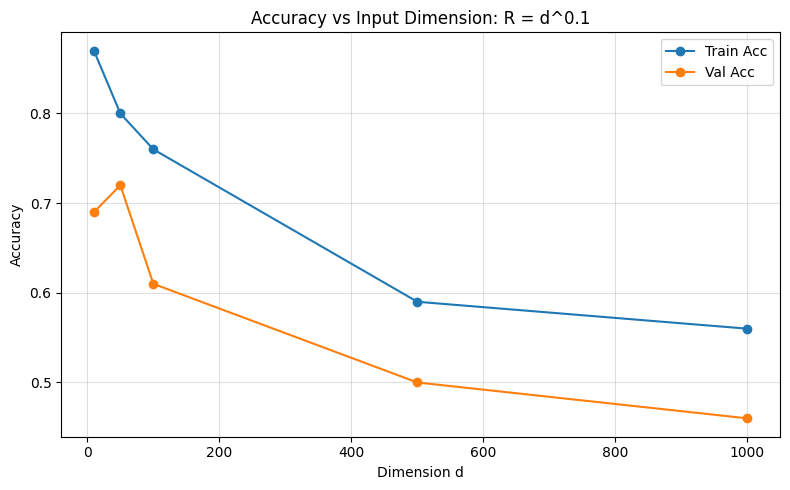

In [130]:
plt.figure(figsize=(8, 5))

plt.plot(ds, train_accs, marker='o', label="Train Acc")
plt.plot(ds, val_accs, marker='o', label="Val Acc")

plt.xlabel("Dimension d")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Input Dimension: R = d^0.1")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [123]:
ds = [10, 50, 100, 500, 1000]
train_accs, val_accs = [], []

for d in ds:
    B, N = 100, 20
    R = d ** 0.3
    _, train_acc, val_acc = train(d, B, N, R, label_flip_p=0.2, val_every=50)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

Step     0 | train loss = 0.6931 | train acc = 0.540 | val loss= 0.6919 | val acc = 0.730
Step    50 | train loss = 0.5302 | train acc = 0.990 | val loss= 0.6266 | val acc = 0.810
Step   100 | train loss = 0.4351 | train acc = 0.980 | val loss= 0.6143 | val acc = 0.740
Step   150 | train loss = 0.3946 | train acc = 0.970 | val loss= 0.6086 | val acc = 0.730
Step   200 | train loss = 0.3133 | train acc = 0.990 | val loss= 0.5746 | val acc = 0.770
Step   250 | train loss = 0.2665 | train acc = 0.990 | val loss= 0.5888 | val acc = 0.750
Step     0 | train loss = 0.6931 | train acc = 0.520 | val loss= 0.6910 | val acc = 0.710
Step    50 | train loss = 0.5023 | train acc = 0.990 | val loss= 0.5904 | val acc = 0.890
Step   100 | train loss = 0.3735 | train acc = 1.000 | val loss= 0.5570 | val acc = 0.840
Step   150 | train loss = 0.3084 | train acc = 1.000 | val loss= 0.5759 | val acc = 0.790
Step   200 | train loss = 0.2480 | train acc = 1.000 | val loss= 0.5968 | val acc = 0.730
Step   250

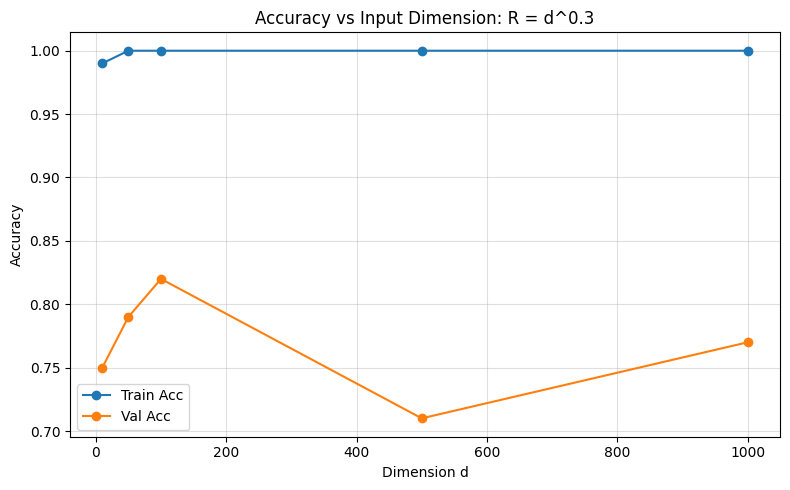

In [128]:
plt.figure(figsize=(8, 5))

plt.plot(ds, train_accs, marker='o', label="Train Acc")
plt.plot(ds, val_accs, marker='o', label="Val Acc")

plt.xlabel("Dimension d")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Input Dimension: R = d^0.3")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()